# Multi-day, SOC-aware EV charging sampler

This notebook runs the `multiday_charging` subproject end to end:

1. **Fleet** with different battery capacities and a preferred charging interval (charge every *k* days).
2. **Short-distance trip profile** with destination labels (Home / Work / Public), from the parent SDPTM table if present, else synthetic.
3. **Empirical session pool** (home, work, public L2, public DC) from `charging_session_all_clean.pkl`.
4. **Location probability matrix** (Home / Work / Public).
5. **Charging-frequency probability matrix** (charge every 1..7 days).
6. **SOC-aware sampling**: a vehicle charges when its preferred interval elapses **or** its battery would be depleted (so battery capacity lets a vehicle skip days).

It simulates **365 days** and plots (a) all 365 daily load curves and (b) the 5–95th-percentile band per hour.

> **All configuration lives in the single config cell below** — edit it to test different settings, then *Run All*.

In [35]:
## Bootstrap: make the subproject + parent `common.py` importable
import sys
import importlib
from pathlib import Path

_here = Path.cwd()
_mod_dir = None
for _c in (_here, _here / "multiday_charging", _here.parent):
    if (_c / "config.py").exists():
        _mod_dir = _c
        break
if _mod_dir is None:
    raise RuntimeError("Could not locate multiday_charging/config.py; run from the subproject folder.")

sys.path.insert(0, str(_mod_dir))            # multiday_charging/
sys.path.insert(0, str(_mod_dir.parent))     # Distribution-Grid-EV-CA/ (for common.py)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import config
import fleet as F
import trips as T
import session_pool as P
import choice as C
import sampling as S
import load_profile as L

# Pick up edits to .py files without restarting the kernel.
for _m in (config, F, T, P, C, S, L):
    importlib.reload(_m)

from config import MultiDayConfig

print("modules loaded from:", _mod_dir)
print("MultiDayConfig has store_sessions:", hasattr(MultiDayConfig, "__dataclass_fields__") and "store_sessions" in MultiDayConfig.__dataclass_fields__)

modules loaded from: e:\GitHub\good_model\Distribution-Grid-EV-CA\multiday_charging
MultiDayConfig has store_sessions: True


## 1. Configuration (edit everything here)

This single cell holds the fleet mix, both probability matrices, and the daily-driving model. Change values and re-run the notebook to test scenarios.

In [36]:
cfg = MultiDayConfig(
    # ---- reproducibility / size ----
    seed=42,
    #n_vehicles=250_000,
    n_vehicles=2_500_000,
    n_days=365,
    # Full CA fleet: build hourly load only (no multi-hundred-GB session table).
    store_sessions=False,

    # ---- vehicle energy model ----
    # battery capacity mix {kWh: share}
    battery_mix={40.0: 0.15, 60.0: 0.35, 75.0: 0.25, 100.0: 0.20, 130.0: 0.05},
    efficiency_mi_per_kwh=3.0,   # 3 mi/kWh == legacy dist/3 rule
    reserve_soc=0.10,            # never deplete below 10% of pack

    # ---- (5) charging-FREQUENCY probability matrix: charge every k days ----
    charge_interval_probs={1: 0.45, 2: 0.25, 3: 0.15, 4: 0.07, 5: 0.04, 6: 0.02, 7: 0.02},

    # ---- (4) charging-LOCATION energy shares (Reference_Code RAW_SHARES) ----
    # Fleet-wide recharge kWh fractions: home 0.68, work 0.04, public 0.28.
    # public_level_weights below split public into DC 0.20 + L2 0.08 of fleet total.
    location_weights={"home": 0.68, "work": 0.04, "public": 0.28},
    location_selection="energy_budget",  # or "session_prob" for legacy per-session lottery
    home_access_share=0.80, # share of vehicles that have home access
    work_access_share=0.30, # share of vehicles that have work access
    work_trip_prob=0.62, # probability of work trip
    public_trip_prob=0.85, # probability of public-eligible trip

    # ---- public DC/L2 energy shares (absolute fleet fractions, sum to public) ----
    public_level_weights={"DC": 0.20, "L2": 0.08},
    home_housing_weights={"single family": 56.4, "multi family": 38.9},

    # ---- daily driving model ----
    mean_daily_vmt=35.0,
    vmt_between_vehicle_cv=0.45, # between vehicle variability, SD/mean
    vmt_day_to_day_cv=0.55, # day-to-day variability, SD/mean
    no_travel_prob=0.08, # probability of no travel
)

# Optional: calibrate the fleet's daily VMT + work access from the real SDPTM
# trip table when it is available (set to False for a fully synthetic run).
CALIBRATE_FROM_REAL_TRIPS = True

rng = np.random.default_rng(cfg.seed)
cfg

MultiDayConfig(seed=42, n_vehicles=2500000, n_days=365, store_sessions=False, battery_mix={40.0: 0.15, 60.0: 0.35, 75.0: 0.25, 100.0: 0.2, 130.0: 0.05}, efficiency_mi_per_kwh=3.0, reserve_soc=0.1, charge_interval_probs={1: 0.45, 2: 0.25, 3: 0.15, 4: 0.07, 5: 0.04, 6: 0.02, 7: 0.02}, location_weights={'home': 0.68, 'work': 0.04, 'public': 0.28}, location_selection='energy_budget', home_access_share=0.8, work_access_share=0.3, work_trip_prob=0.62, public_trip_prob=0.85, public_level_weights={'DC': 0.2, 'L2': 0.08}, home_housing_weights={'single family': 56.4, 'multi family': 38.9}, mean_daily_vmt=35.0, vmt_between_vehicle_cv=0.45, vmt_day_to_day_cv=0.55, no_travel_prob=0.08, bin_edges=(0, 5, 10, 15, 20, 30, 50, 80, inf), base_dir=WindowsPath('E:/GitHub/good_model/Distribution-Grid-EV-CA'), sd_trips_pkl='data/mobility_data/CSTDM_processed/EV trips_new_SDPTM_sample42.pkl', sd_trips_profiles_pkl='data/mobility_data/CSTDM_processed/EV trips_new_SDPTM_sample42_profiles.pkl', session_pool_pkl=

## 2. Build the fleet (battery capacity + charging-frequency preference)

In [37]:
fleet = F.build_fleet(cfg, rng)

# (2) short-distance trip profile with destination labels (real if available)
profiles = T.load_sd_trip_profiles(cfg)
if profiles is not None and CALIBRATE_FROM_REAL_TRIPS:
    print(f"Calibrating fleet from {len(profiles):,} real SDPTM vehicle profiles")
    fleet = T.calibrate_fleet_from_trips(cfg, fleet, profiles, rng)
else:
    print("Using synthetic daily-driving profile (no real SDPTM table found / calibration off)")

# Assign each vehicle a home TAZ (for TAZ-level demand reporting)
fleet = T.assign_home_taz(cfg, fleet, rng)

display(F.fleet_summary(fleet))
fleet[["vehicle_id", "battery_kwh", "mean_daily_vmt", "home_taz"]].head()

Calibrating fleet from 2,220,087 real SDPTM vehicle profiles


,metric,value
0,n_vehicles,2500000.000
1,mean_battery_kwh,72.250
2,home_access_share,0.800
3,work_access_share,0.257
4,mean_interval_pref_days,2.140
5,mean_daily_vmt,79.350


,vehicle_id,battery_kwh,mean_daily_vmt,home_taz
0,0,100.0,151.039993,6046
1,1,60.0,28.000000,2866
2,2,100.0,53.639999,6225
3,3,75.0,259.360016,5276
4,4,40.0,140.979996,1245


## 3. Daily driving inputs (365 days) and 4. empirical session pool

In [38]:
# day-varying VMT + location availability over the 365-day horizon
daily = T.build_daily_inputs(cfg, fleet, rng)
print("daily VMT matrix:", daily["vmt"].shape,
      "| mean daily VMT:", round(float(daily["vmt"].mean()), 2), "mi")

# (3) empirical session pool (~6.5M cleaned sessions)
pool = P.build_session_pool(cfg, rng)
print("session pool source:", pool.attrs.get("source"), "| rows:", len(pool))
display(P.pool_coverage(pool).head(12))

daily VMT matrix: (2500000, 365) | mean daily VMT: 73.0 mi
session pool source: empirical | rows: 6515297


,charge_type,charger_level,bin,n
0,home,L2,1,407155
1,home,L2,2,69609
2,home,L2,3,29137
3,home,L2,4,13558
4,public,DC,1,473719
5,public,DC,2,1084208
6,public,DC,3,1129079
7,public,DC,4,797544
8,public,DC,5,415934
9,public,DC,6,201580


## 5–6. Run the SOC-aware multi-day sampler

In [39]:
result = S.simulate(cfg, fleet, daily, pool, rng)
display(result.summary)

# Target vs realized fleet recharge energy shares (kWh from vehicle depletion)
_summary = result.summary.set_index("metric")["value"]
_energy_targets = {
    "energy_share_home": cfg.location_weights["home"],
    "energy_share_work": cfg.location_weights["work"],
    "energy_share_public": cfg.location_weights["public"],
    "energy_share_dc": cfg.public_level_weights["DC"],
    "energy_share_public_l2": cfg.public_level_weights["L2"],
}
_energy_rows = []
for metric, target in _energy_targets.items():
    realized = float(_summary.get(metric, float("nan")))
    _energy_rows.append({"metric": metric, "target": target, "realized": realized, "delta": realized - target})
display(pd.DataFrame(_energy_rows))
if cfg.home_access_share < 1.0:
    print(
        f"Note: home_access_share={cfg.home_access_share:.0%} caps how much recharge "
        "can occur at home; realized energy_share_home may fall below the 0.68 target."
    )

print("Hourly load matrix:", result.load.shape, "kW (fleet total per hour)")
if result.sessions is not None:
    display(result.sessions.head())

,metric,value
0,total_sessions,5.981316e+08
1,sessions_per_vehicle_day,6.555000e-01
2,share_home,6.896000e-01
3,share_work,2.140000e-02
4,share_public,2.891000e-01
5,energy_share_home,6.885000e-01
6,energy_share_work,2.290000e-02
7,energy_share_public,2.885000e-01
8,energy_share_dc,2.043000e-01
9,energy_share_public_l2,8.430000e-02


,metric,target,realized,delta
0,energy_share_home,0.68,0.6885,0.0085
1,energy_share_work,0.04,0.0229,-0.0171
2,energy_share_public,0.28,0.2885,0.0085
3,energy_share_dc,0.20,0.2043,0.0043
4,energy_share_public_l2,0.08,0.0843,0.0043


Note: home_access_share=80% caps how much recharge can occur at home; realized energy_share_home may fall below the 0.68 target.
Hourly load matrix: (365, 24) kW (fleet total per hour)


## Total charging demand by TAZ

Annual recharge energy (kWh) aggregated by TAZ:
- **Home** sessions → vehicle's assigned **home TAZ** (from `EVhh_new_SDPTM_sample42.csv`)
- **Work / public** sessions → TAZ drawn proportional to the EV-household count per TAZ (destination proxy when trip-level TAZ is unavailable)

TAZs with demand: 5,156
Annual fleet recharge energy: 17,814.54 GWh


,TAZ,home_kwh,work_kwh,public_kwh,total_kwh
0,432,6.481790e+07,2.137152e+06,2.682478e+07,9.377984e+07
1,712,4.208902e+07,1.422649e+06,1.767481e+07,6.118648e+07
2,6016,4.067915e+07,1.330418e+06,1.683757e+07,5.884714e+07
3,6670,3.916707e+07,1.303713e+06,1.633296e+07,5.680375e+07
4,3615,3.773648e+07,1.254190e+06,1.574533e+07,5.473600e+07
5,1677,3.180475e+07,1.063239e+06,1.334727e+07,4.621526e+07
6,5930,2.615775e+07,8.640367e+05,1.096640e+07,3.798819e+07
7,778,2.607904e+07,8.657215e+05,1.084044e+07,3.778520e+07
8,5260,2.465486e+07,8.262258e+05,1.042180e+07,3.590288e+07
9,1366,2.439674e+07,8.111080e+05,1.022610e+07,3.543395e+07


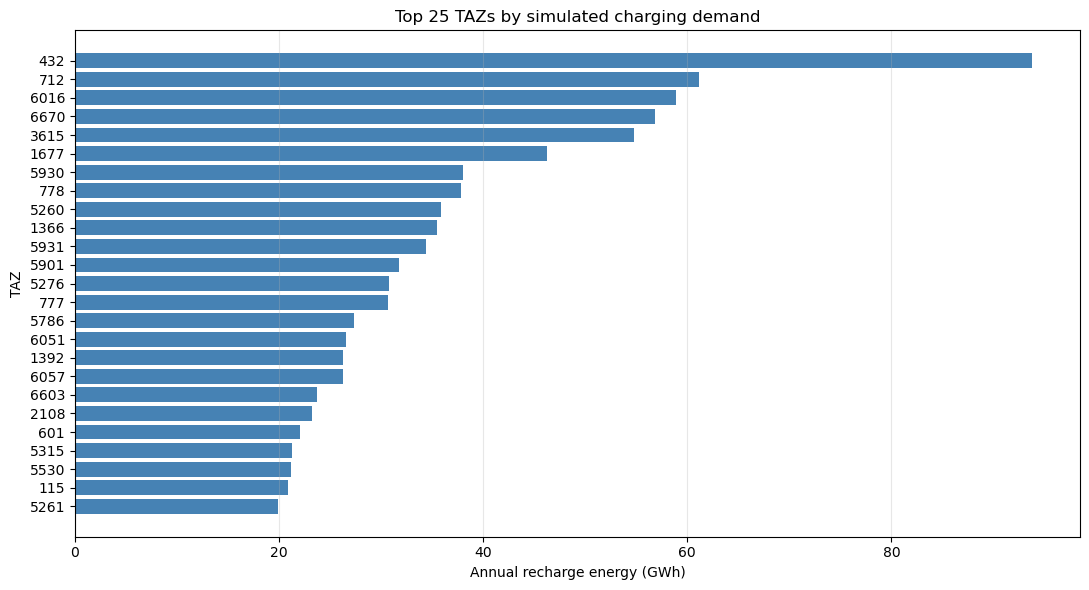

saved: E:\GitHub\good_model\Distribution-Grid-EV-CA\multiday_charging\outputs\taz_total_demand_kwh.csv


In [40]:
taz_demand = result.taz_demand_kwh
if taz_demand is None:
    raise RuntimeError("TAZ demand table missing — ensure fleet has home_taz (run fleet cell above).")

print(f"TAZs with demand: {len(taz_demand):,}")
print(f"Annual fleet recharge energy: {taz_demand['total_kwh'].sum() / 1e6:,.2f} GWh")
display(taz_demand.head(20))

# Top 25 TAZs by total annual recharge energy
fig, ax = plt.subplots(figsize=(11, 6))
top = taz_demand.head(25).sort_values("total_kwh")
ax.barh(top["TAZ"].astype(str), top["total_kwh"] / 1e6, color="steelblue")
ax.set_xlabel("Annual recharge energy (GWh)")
ax.set_ylabel("TAZ")
ax.set_title("Top 25 TAZs by simulated charging demand")
ax.grid(axis="x", alpha=0.3)
fig.tight_layout()
plt.show()

out_dir = cfg.out_path()
taz_demand.to_csv(out_dir / "taz_total_demand_kwh.csv", index=False)
print("saved:", out_dir / "taz_total_demand_kwh.csv")

## Map — annual charging demand by TAZ

Choropleth maps joined to CSTDM TAZ polygons (`data/shps/taz_id.shp`, field `TAZ12`):
- **Total** — all charging energy
- **Home / work / public** — demand by location type

TAZs with no simulated demand for a given layer are shown in grey. Color scales use GWh on a log scale (5th–99th percentile of positive values per layer).

TAZ polygons with total demand > 0: 5,156 / 5,454


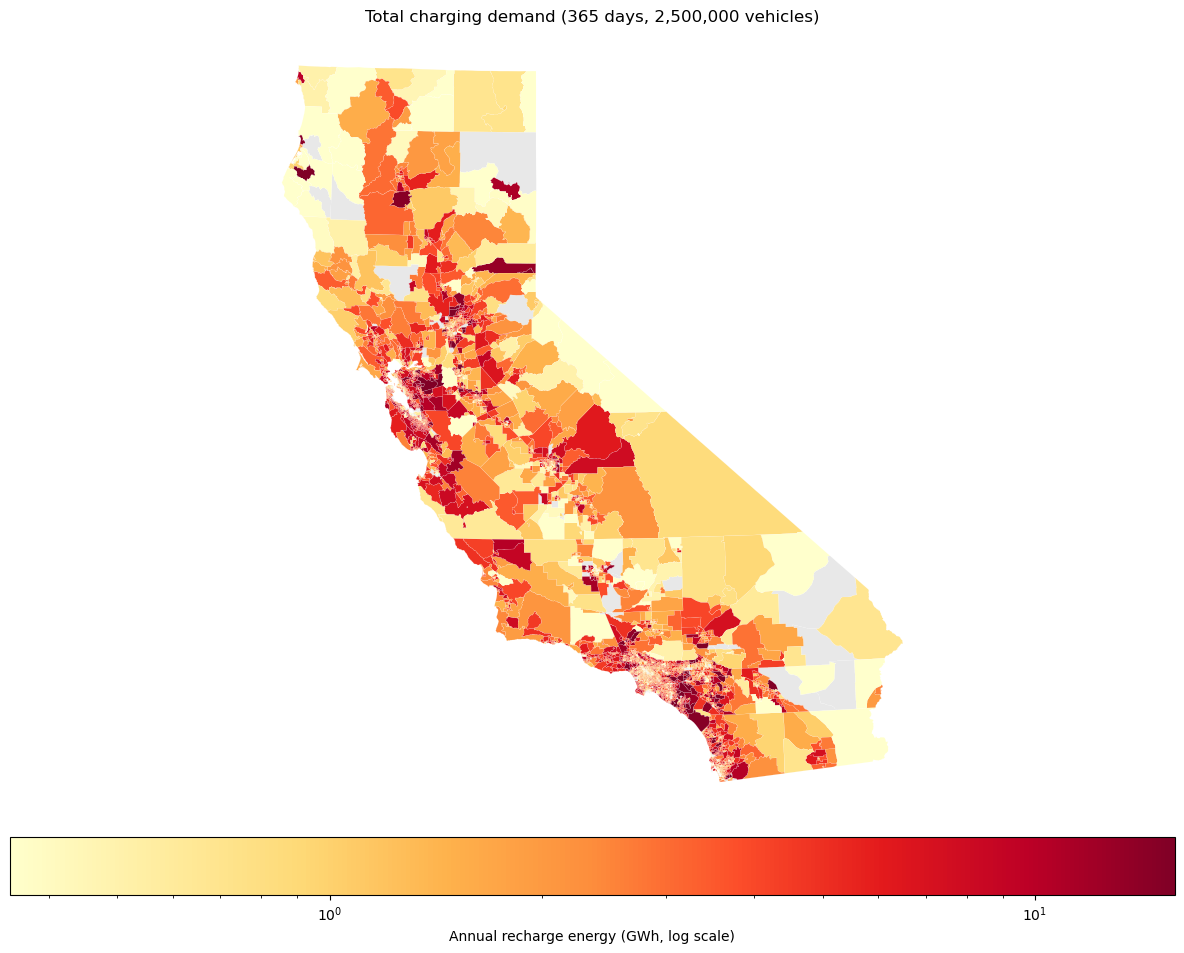

saved: E:\GitHub\good_model\Distribution-Grid-EV-CA\multiday_charging\outputs\taz_total_demand_map.png


In [41]:
import matplotlib.colors as mcolors

try:
    import geopandas as gpd
except ImportError as e:
    raise ImportError(
        "geopandas is required for the TAZ map. Install with: pip install geopandas"
    ) from e

taz_shp = cfg.base_dir / "data" / "shps" / "taz_id.shp"
if not taz_shp.is_file():
    raise FileNotFoundError(f"Missing TAZ shapefile: {taz_shp}")

taz_geo = gpd.read_file(taz_shp)[["TAZ12", "geometry"]].copy()
taz_geo["TAZ12"] = taz_geo["TAZ12"].astype(int)

demand_map = taz_geo.merge(
    taz_demand.rename(columns={"TAZ": "TAZ12"}),
    on="TAZ12",
    how="left",
)
for _col in ("total_kwh", "home_kwh", "work_kwh", "public_kwh"):
    demand_map[_col] = demand_map[_col].fillna(0)
for _col in ("total", "home", "work", "public"):
    demand_map[f"{_col}_gwh"] = demand_map[f"{_col}_kwh"] / 1e6


def plot_taz_demand_layer(
    gdf,
    col_gwh: str,
    ax,
    title: str,
    cmap: str = "YlOrRd",
) -> int:
    """Choropleth for one demand layer; returns count of TAZs with demand > 0."""
    has_demand = gdf[col_gwh] > 0
    pos = gdf.loc[has_demand, col_gwh]
    if len(pos):
        vmin = max(float(pos.quantile(0.05)), 1e-6)
        vmax = max(float(pos.quantile(0.99)), vmin * 10)
    else:
        vmin, vmax = 1e-6, 1.0
    norm = mcolors.LogNorm(vmin=vmin, vmax=vmax)

    gdf.loc[~has_demand].plot(
        ax=ax,
        color="#e8e8e8",
        edgecolor="white",
        linewidth=0.08,
    )
    gdf.loc[has_demand].plot(
        column=col_gwh,
        ax=ax,
        cmap=cmap,
        norm=norm,
        edgecolor="white",
        linewidth=0.08,
        legend=True,
        legend_kwds={
            "label": "Annual recharge energy (GWh, log scale)",
            "orientation": "horizontal",
            "shrink": 0.85,
            "pad": 0.02,
        },
    )
    ax.set_axis_off()
    ax.set_title(title, fontsize=12)
    return int(has_demand.sum())


_sim_title = f"{cfg.n_days} days, {cfg.n_vehicles:,} vehicles"

fig, ax = plt.subplots(figsize=(14, 10))
n_total = plot_taz_demand_layer(
    demand_map,
    "total_gwh",
    ax,
    f"Total charging demand ({_sim_title})",
)
print(f"TAZ polygons with total demand > 0: {n_total:,} / {len(demand_map):,}")
fig.tight_layout()
map_path = out_dir / "taz_total_demand_map.png"
fig.savefig(map_path, dpi=200, bbox_inches="tight")
plt.show()
print("saved:", map_path)

Home charging: 5,156 TAZs with demand > 0
Work charging: 5,156 TAZs with demand > 0
Public charging: 5,156 TAZs with demand > 0


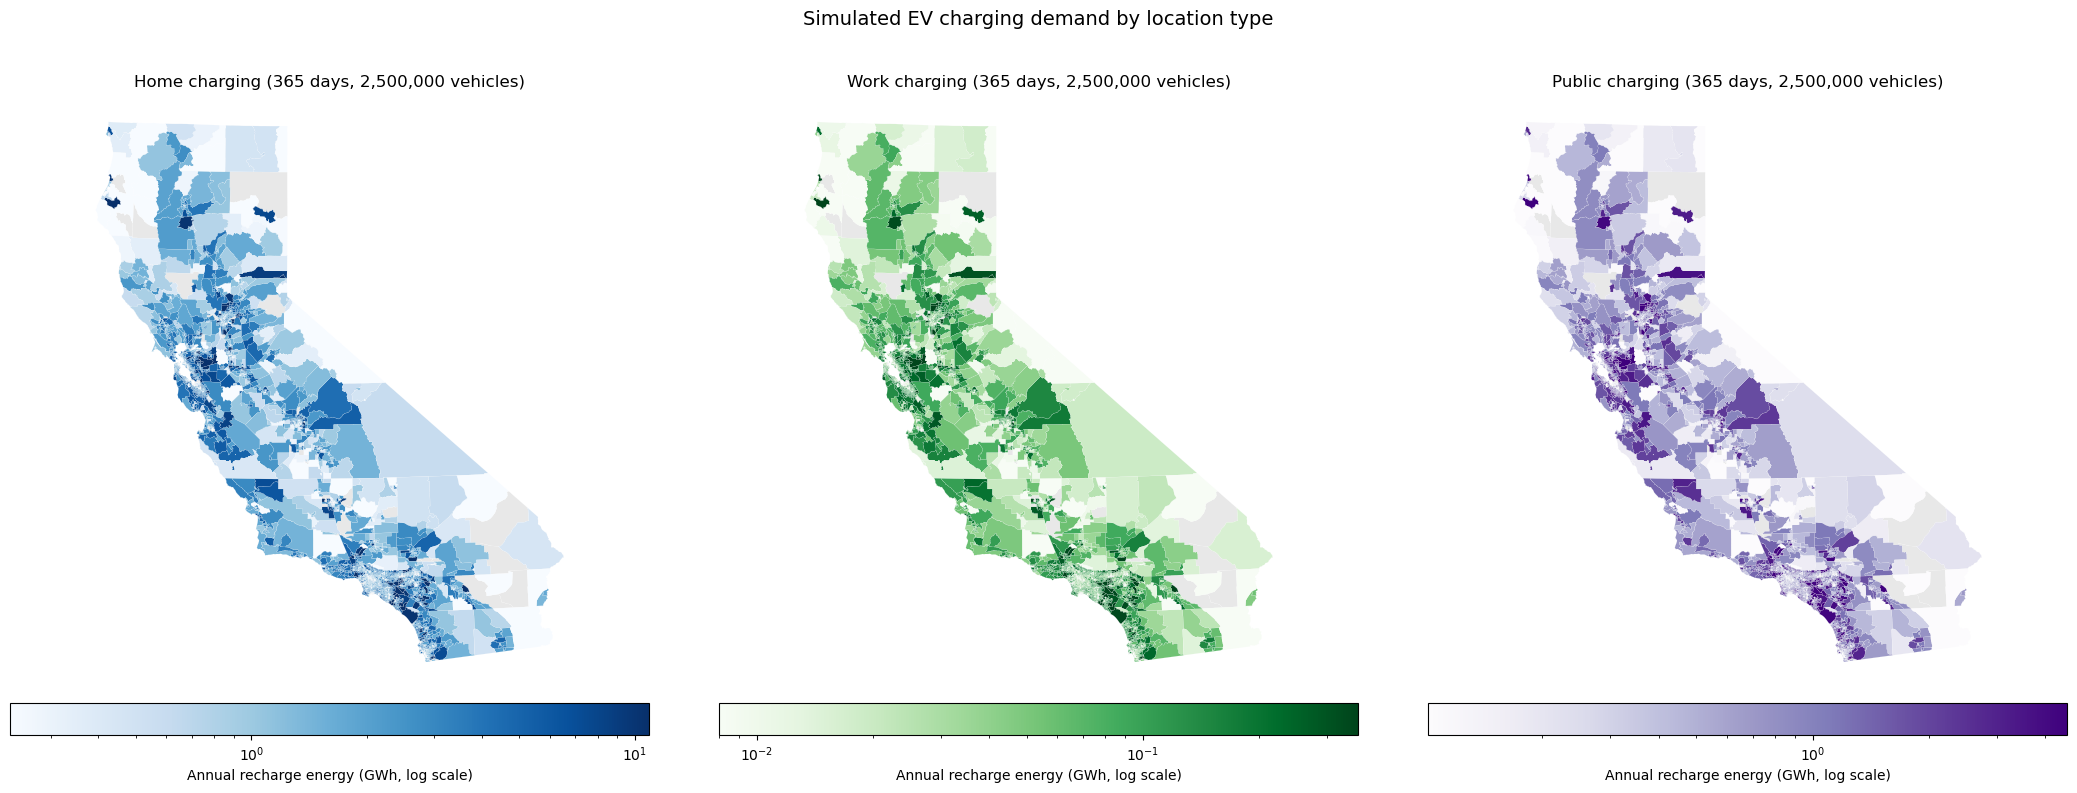

saved: E:\GitHub\good_model\Distribution-Grid-EV-CA\multiday_charging\outputs\taz_demand_by_type_maps.png


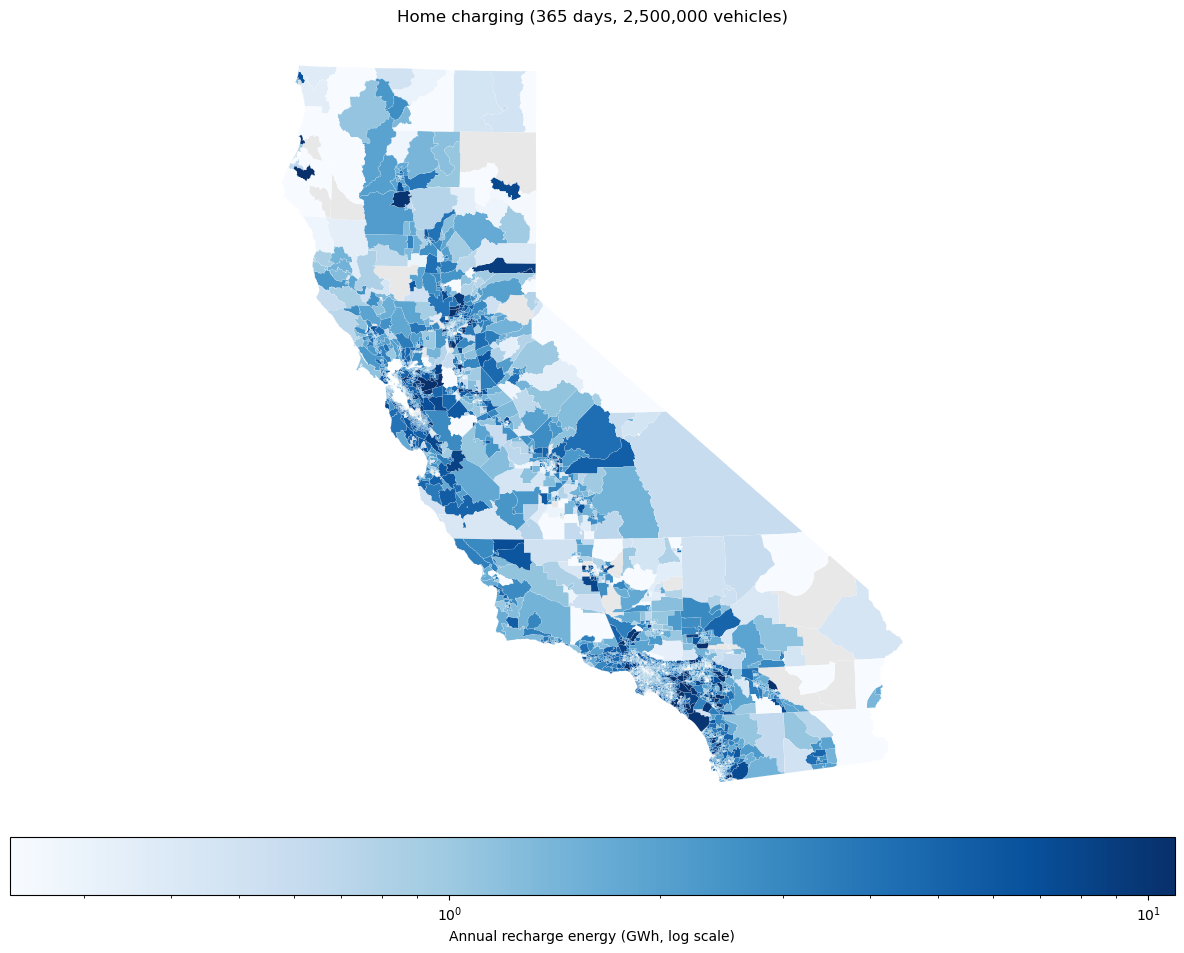

saved: E:\GitHub\good_model\Distribution-Grid-EV-CA\multiday_charging\outputs\taz_home_demand_map.png


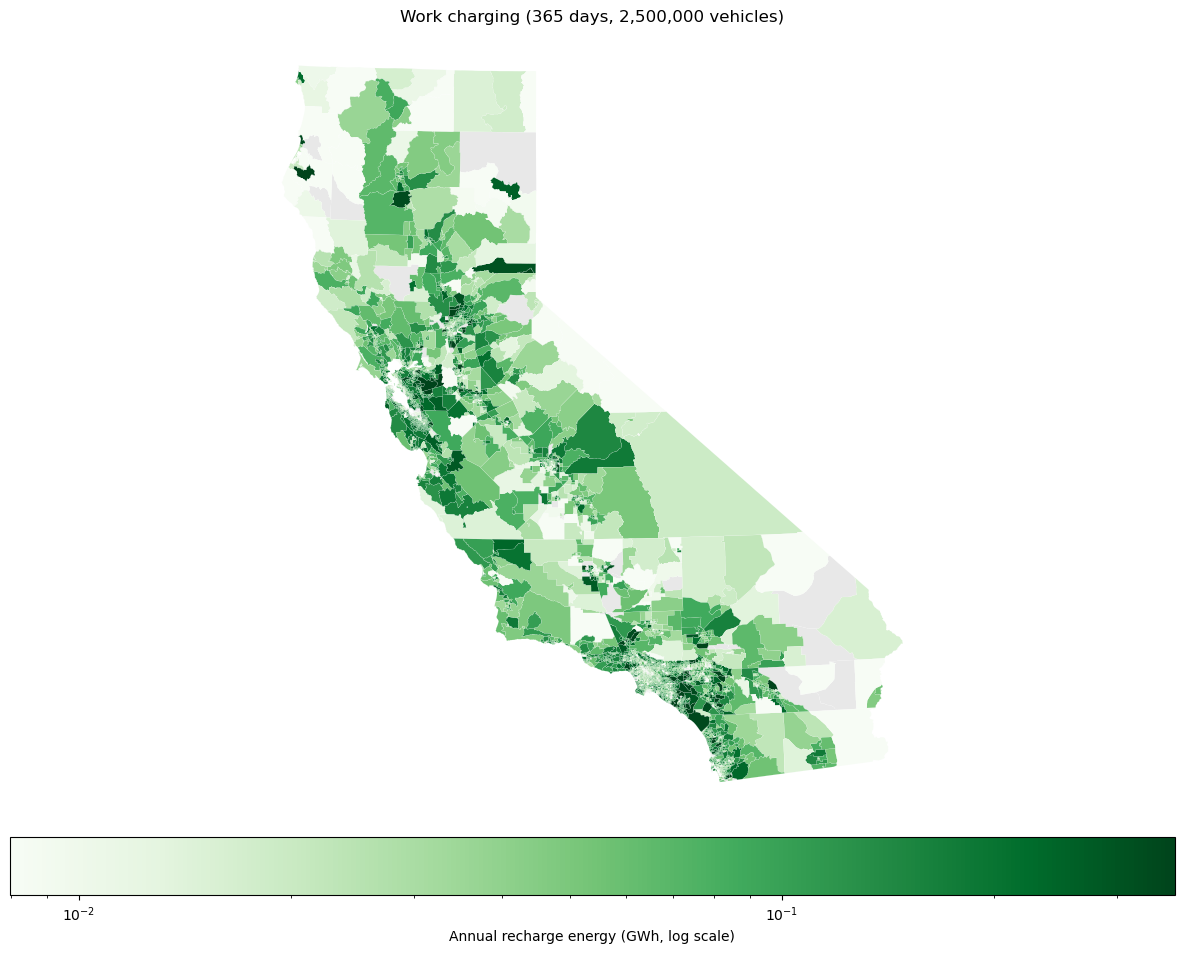

saved: E:\GitHub\good_model\Distribution-Grid-EV-CA\multiday_charging\outputs\taz_work_demand_map.png


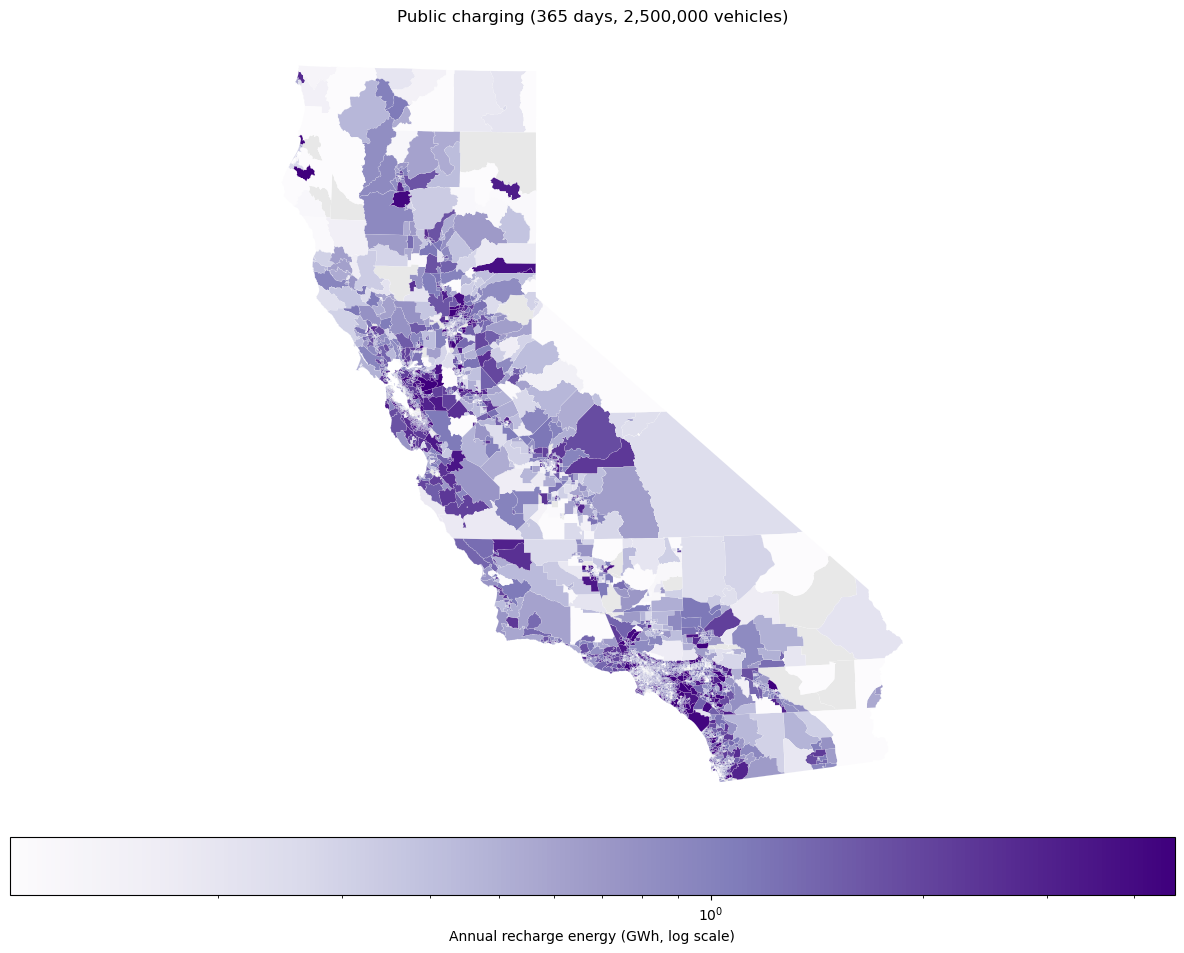

saved: E:\GitHub\good_model\Distribution-Grid-EV-CA\multiday_charging\outputs\taz_public_demand_map.png


In [42]:
type_layers = [
    ("home_gwh", "Home charging", "Blues", "taz_home_demand_map.png"),
    ("work_gwh", "Work charging", "Greens", "taz_work_demand_map.png"),
    ("public_gwh", "Public charging", "Purples", "taz_public_demand_map.png"),
]

fig, axes = plt.subplots(1, 3, figsize=(22, 8))
for ax, (col, title, cmap, _) in zip(axes, type_layers):
    n = plot_taz_demand_layer(demand_map, col, ax, f"{title} ({_sim_title})", cmap=cmap)
    print(f"{title}: {n:,} TAZs with demand > 0")

fig.suptitle("Simulated EV charging demand by location type", fontsize=14, y=1.02)
fig.tight_layout()
combined_path = out_dir / "taz_demand_by_type_maps.png"
fig.savefig(combined_path, dpi=200, bbox_inches="tight")
plt.show()
print("saved:", combined_path)

for col, title, cmap, fname in type_layers:
    fig_i, ax_i = plt.subplots(figsize=(14, 10))
    plot_taz_demand_layer(demand_map, col, ax_i, f"{title} ({_sim_title})", cmap=cmap)
    fig_i.tight_layout()
    path_i = out_dir / fname
    fig_i.savefig(path_i, dpi=200, bbox_inches="tight")
    plt.show()
    print("saved:", path_i)

## Build hourly load profiles (365 days x 24 hours)

In [43]:
load = result.load
load_by_type = result.load_by_type

# convert to MW per vehicle-scale view; here we keep kW (total simulated fleet)
band = L.percentile_band(load, lo=5, hi=95)
print("Overall peak hour-mean (kW):", round(load.mean(0).max(), 1))
display(band)

Overall peak hour-mean (kW): 3262329.9


,hour,p_lo,median,mean,p_hi
0,0,2.119571e+06,2.355147e+06,2.350906e+06,2.601543e+06
1,1,2.009586e+06,2.231170e+06,2.226192e+06,2.457802e+06
2,2,1.841600e+06,2.040474e+06,2.036352e+06,2.243346e+06
3,3,1.640516e+06,1.813132e+06,1.815732e+06,1.996543e+06
4,4,1.411287e+06,1.565336e+06,1.563649e+06,1.727026e+06
5,5,1.245102e+06,1.375745e+06,1.375062e+06,1.521550e+06
6,6,1.175228e+06,1.296150e+06,1.300159e+06,1.438822e+06
7,7,1.164148e+06,1.286513e+06,1.291268e+06,1.429612e+06
8,8,1.284798e+06,1.429917e+06,1.426377e+06,1.577183e+06
9,9,1.415080e+06,1.574617e+06,1.571501e+06,1.738504e+06


## Plot A — all 365 daily load curves

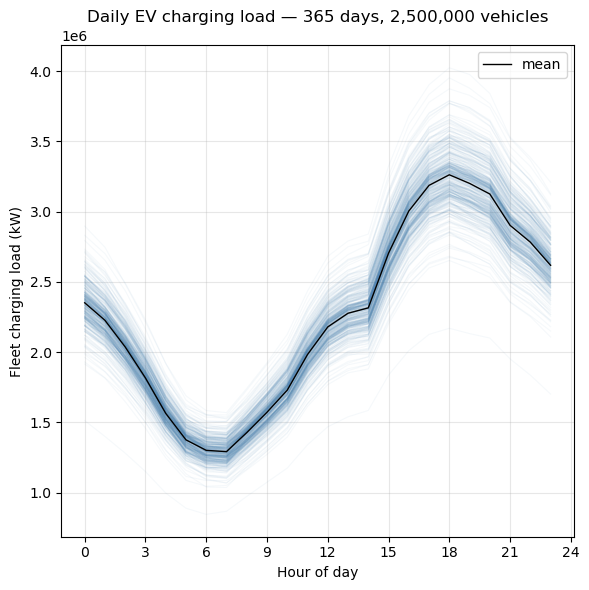

saved: E:\GitHub\good_model\Distribution-Grid-EV-CA\multiday_charging\outputs\daily_load_365_lines.png


In [44]:
out_dir = cfg.out_path()
hours = np.arange(24)

fig, ax = plt.subplots(figsize=(6, 6))
for d in range(cfg.n_days):
    ax.plot(hours, load[d], color="steelblue", alpha=0.05, lw=0.8)
ax.plot(hours, load.mean(0), color="black", lw=1, label="mean")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Fleet charging load (kW)")
ax.set_title(f"Daily EV charging load — {cfg.n_days} days, {cfg.n_vehicles:,} vehicles")
ax.set_xticks(range(0, 25, 3))
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(out_dir / "daily_load_365_lines.png", dpi=200, bbox_inches="tight")
plt.show()
print("saved:", out_dir / "daily_load_365_lines.png")

## Plot B — 5–95th percentile band by hour

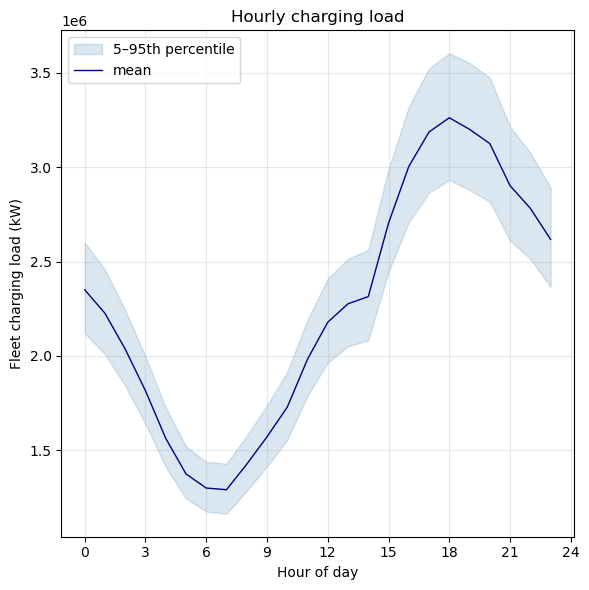

saved: E:\GitHub\good_model\Distribution-Grid-EV-CA\multiday_charging\outputs\hourly_load_percentile_band.png


In [45]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.fill_between(band["hour"], band["p_lo"], band["p_hi"],
                color="steelblue", alpha=0.20, label="5–95th percentile")
#ax.plot(band["hour"], band["median"], color="navy", lw=2.2, label="median")
ax.plot(band["hour"], band["mean"], color="navy", lw=1, ls="-", label="mean")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Fleet charging load (kW)")
ax.set_title("Hourly charging load")
ax.set_xticks(range(0, 25, 3))
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(out_dir / "hourly_load_percentile_band.png", dpi=200, bbox_inches="tight")
plt.show()
print("saved:", out_dir / "hourly_load_percentile_band.png")

## Plot C — mean daily load decomposed by charge type

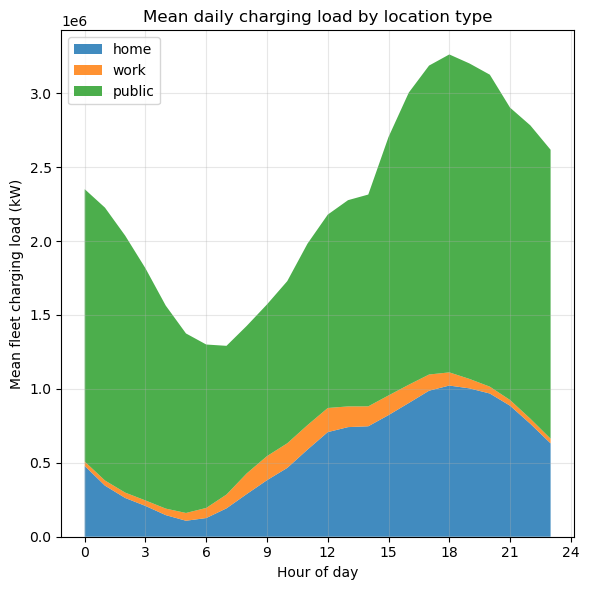

outputs written to: E:\GitHub\good_model\Distribution-Grid-EV-CA\multiday_charging\outputs


In [46]:
fig, ax = plt.subplots(figsize=(6, 6))
order = [t for t in ("home", "work", "public") if t in load_by_type]
means = [load_by_type[t].mean(0) for t in order]
ax.stackplot(hours, *means, labels=order, alpha=0.85)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Mean fleet charging load (kW)")
ax.set_title("Mean daily charging load by location type")
ax.set_xticks(range(0, 25, 3))
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(out_dir / "mean_load_by_type.png", dpi=200, bbox_inches="tight")
plt.show()

# persist the matrices for downstream use
np.save(out_dir / "daily_hourly_load_kW.npy", load)
band.to_csv(out_dir / "hourly_percentile_band.csv", index=False)
if result.sessions is not None:
    result.sessions.to_parquet(out_dir / "sampled_sessions.parquet")
print("outputs written to:", out_dir)

## Notes & extensions

- **Battery capacity** enters through `usable_kwh = battery * (1 - reserve_soc)`: a vehicle is forced to charge once cumulative depletion reaches the usable pack, so larger packs skip more days even if the frequency preference is short.
- **Charging-frequency matrix** (`charge_interval_probs`) sets each vehicle's *preferred* interval; battery depletion can override it.
- **Location energy shares** (`location_weights`, default `location_selection="energy_budget"`) allocate each day's recharge kWh greedily toward home/work/public targets (Reference RAW_SHARES). Per-day feasibility (home access, work visit, public availability) still applies; session-count shares (`share_*`) will differ from energy shares (`energy_share_*`).
- To produce **block / TAZ-level** curves, attach a `zone` column to `sessions` (e.g. from the block→TAZ crosswalk) and call `L.grouped_daily_hourly(sessions, "zone", cfg.n_days)`.
- The empirical pool at `data/charging data/charging_session_all_clean.pkl` is required (rebuild with `build_multiday_inputs.py` if needed).